# 🔧 Ingeniería de Características - Proyecto Orion

## Objetivo
Explorar las características extraídas por el sistema Orion:
- Features de consumo (media, desviación, CV, etc.)
- Features de alarmas
- Features de facturación
- Importancia de features en el modelo

In [1]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN
# ============================================================

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from src.utilidades.tiempo import ahora_peru

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

print(f"📅 Hora Perú: {ahora_peru().strftime('%Y-%m-%d %H:%M:%S')}")
print("✅ Librerías cargadas")

2026-09-10 23:02:59 | INFO     | src.utilidades.registrador:configurar_registrador:39 - 📋 Sistema de registro inicializado
📅 Hora Perú: 2026-09-10 23:02:59
✅ Librerías cargadas


## 1. Cargar Features Extraídas

Cargamos las features generadas por `ExtractorCaracteristicas`.

In [2]:
# ============================================================
# CARGAR FEATURES
# ============================================================

# Cargar puntajes (contiene las features)
puntajes_path = Path('../datos/procesados/puntajes_latest.parquet')

if puntajes_path.exists():
    df = pd.read_parquet(puntajes_path)
    print(f"✅ Features cargadas: {len(df)} registros")
    print(f"📊 Columnas: {df.columns.tolist()}")
    
    display(df.head())
else:
    print("⚠️ No hay features disponibles")
    print("💡 Ejecuta: python scripts/ejecutar_flujo_completo.py")

✅ Features cargadas: 200 registros
📊 Columnas: ['id_cliente', 'alarmas_tipo_bypass', 'alarmas_precinto_roto', 'alarmas_tapa_abierta', 'alarmas_inversion_fases', 'alarmas_ultimos_30_dias', 'score_evidencia_fisica', 'caida_brusca', 'meses_con_caida', 'consumo_vs_similares', 'consumo_minimo_sostenido', 'ratio_consumo_nocturno', 'score_evidencia_consumo', 'hurto_confirmado_previo', 'inspecciones_previas', 'tasa_exito_historica', 'meses_desde_ultima_inspeccion', 'score_reincidencia', 'probabilidad', 'impacto_economico', 'historial', 'puntaje_prioridad', 'prioridad']


,id_cliente,alarmas_tipo_bypass,alarmas_precinto_roto,alarmas_tapa_abierta,alarmas_inversion_fases,alarmas_ultimos_30_dias,score_evidencia_fisica,caida_brusca,meses_con_caida,consumo_vs_similares,consumo_minimo_sostenido,ratio_consumo_nocturno,score_evidencia_consumo,hurto_confirmado_previo,inspecciones_previas,tasa_exito_historica,meses_desde_ultima_inspeccion,score_reincidencia,probabilidad,impacto_economico,historial,puntaje_prioridad,prioridad
0,CL-00044,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0,6.667613,277.878917,1.0,0.021193,0.0,1.0,0.000000,10.0,0.197998,0.909320,0.954219,0.25,1.000000,ALTA
1,CL-00054,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0,6.987511,292.116582,1.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.894827,1.000000,0.00,0.944986,ALTA
2,CL-00012,0.0,0.0,1.0,0.0,0.0,0.045455,0.0,0,5.611641,215.824090,1.0,0.101460,0.0,0.0,0.000000,0.0,0.000000,0.969910,0.803096,0.00,0.917765,ALTA
3,CL-00183,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0,4.576773,187.261208,1.0,0.158042,1.0,1.0,0.990099,11.0,0.994828,0.924694,0.654993,0.25,0.896222,ALTA
4,CL-00187,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0,6.574611,266.078121,1.0,0.032600,0.0,0.0,0.000000,0.0,0.000000,0.817222,0.940909,0.00,0.873513,ALTA


## 2. Análisis de Features

Exploramos las características extraídas.

In [3]:
# ============================================================
# ANÁLISIS DE FEATURES
# ============================================================

if puntajes_path.exists():
    # Identificar features numéricas
    columnas_excluir = ['id_cliente', 'prioridad']
    features_num = [col for col in df.columns 
                    if col not in columnas_excluir 
                    and df[col].dtype in ['float64', 'int64', 'float32', 'int32']]
    
    print(f"📊 Features numéricas: {len(features_num)}")
    print(f"📋 Lista: {features_num}")
    
    # Estadísticas descriptivas
    if features_num:
        print("\n📊 Estadísticas descriptivas:")
        display(df[features_num].describe())

📊 Features numéricas: 21
📋 Lista: ['alarmas_tipo_bypass', 'alarmas_precinto_roto', 'alarmas_tapa_abierta', 'alarmas_inversion_fases', 'alarmas_ultimos_30_dias', 'score_evidencia_fisica', 'caida_brusca', 'meses_con_caida', 'consumo_vs_similares', 'consumo_minimo_sostenido', 'ratio_consumo_nocturno', 'score_evidencia_consumo', 'hurto_confirmado_previo', 'inspecciones_previas', 'tasa_exito_historica', 'meses_desde_ultima_inspeccion', 'score_reincidencia', 'probabilidad', 'impacto_economico', 'historial', 'puntaje_prioridad']

📊 Estadísticas descriptivas:


,alarmas_tipo_bypass,alarmas_precinto_roto,alarmas_tapa_abierta,alarmas_inversion_fases,alarmas_ultimos_30_dias,score_evidencia_fisica,caida_brusca,meses_con_caida,consumo_vs_similares,consumo_minimo_sostenido,ratio_consumo_nocturno,score_evidencia_consumo,hurto_confirmado_previo,inspecciones_previas,tasa_exito_historica,meses_desde_ultima_inspeccion,score_reincidencia,probabilidad,impacto_economico,historial,puntaje_prioridad
count,200.000000,200.000000,200.000000,200.000000,200.0,200.000000,200.000000,200.000000,200.000000,200.000000,200.0,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000
mean,0.100000,0.100000,0.190000,0.020000,0.0,0.037273,0.018512,0.195000,0.999783,35.340982,1.0,0.418667,0.145000,0.400000,0.136176,5.185000,0.189315,0.484006,0.143081,0.10000,0.385532
std,0.558174,0.448336,0.463654,0.172478,0.0,0.126120,0.095954,0.527605,1.276843,48.471006,0.0,0.118149,0.352984,0.520919,0.336412,6.809008,0.336756,0.294891,0.182732,0.13023,0.207352
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.188842,4.320000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005522,0.027026,0.00000,0.027704
25%,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.341271,12.485631,1.0,0.398445,0.000000,0.000000,0.000000,0.000000,0.000000,0.228582,0.048840,0.00000,0.202099
50%,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.483866,17.156086,1.0,0.422541,0.000000,0.000000,0.000000,0.000000,0.000000,0.494486,0.069247,0.00000,0.393154
75%,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.078799,36.263401,1.0,0.432739,0.000000,1.000000,0.000000,12.000000,0.197247,0.756860,0.154390,0.25000,0.548925
max,5.000000,3.000000,2.000000,2.000000,0.0,1.000000,0.709386,2.000000,6.987511,292.116582,1.0,0.957650,1.000000,2.000000,0.990099,19.000000,0.995228,0.986887,1.000000,0.50000,1.000000


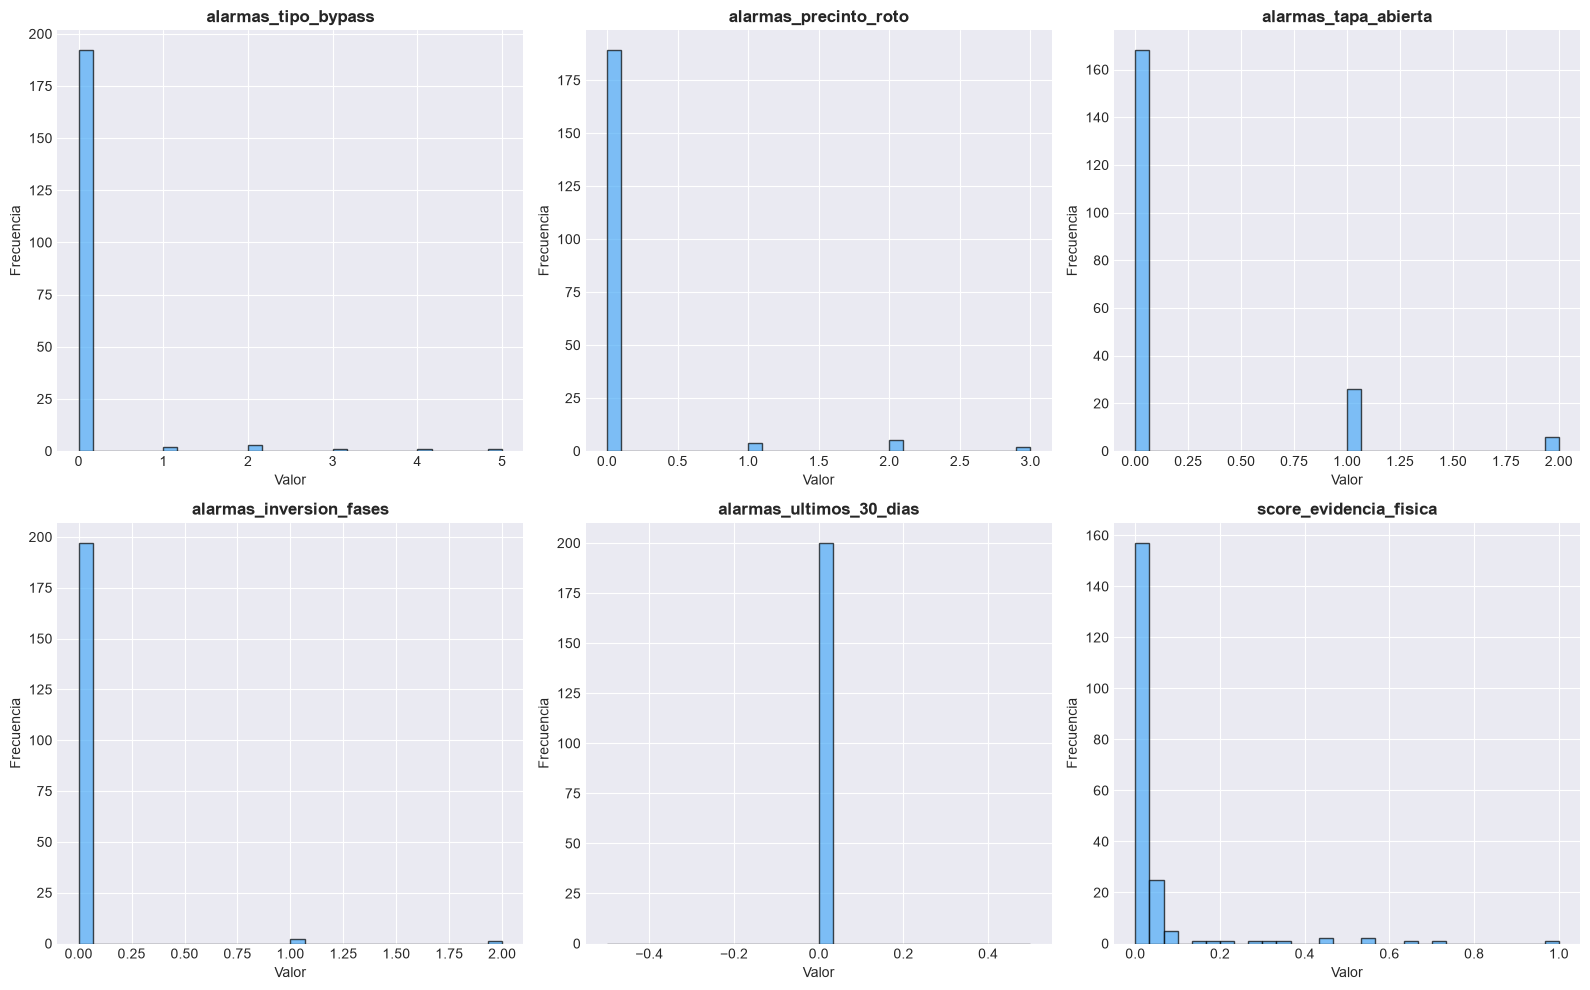

In [4]:
# ============================================================
# VISUALIZACIÓN DE FEATURES
# ============================================================

if puntajes_path.exists() and features_num:
    # Seleccionar las primeras 6 features para visualizar
    features_viz = features_num[:6]
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, feature in enumerate(features_viz):
        if i < len(axes):
            axes[i].hist(df[feature].dropna(), bins=30, 
                         color='#4dabf7', edgecolor='black', alpha=0.7)
            axes[i].set_title(f'{feature}', fontweight='bold')
            axes[i].set_xlabel('Valor')
            axes[i].set_ylabel('Frecuencia')
    
    plt.tight_layout()
    plt.show()

## 3. Correlación entre Features

Analizamos la correlación entre las características.

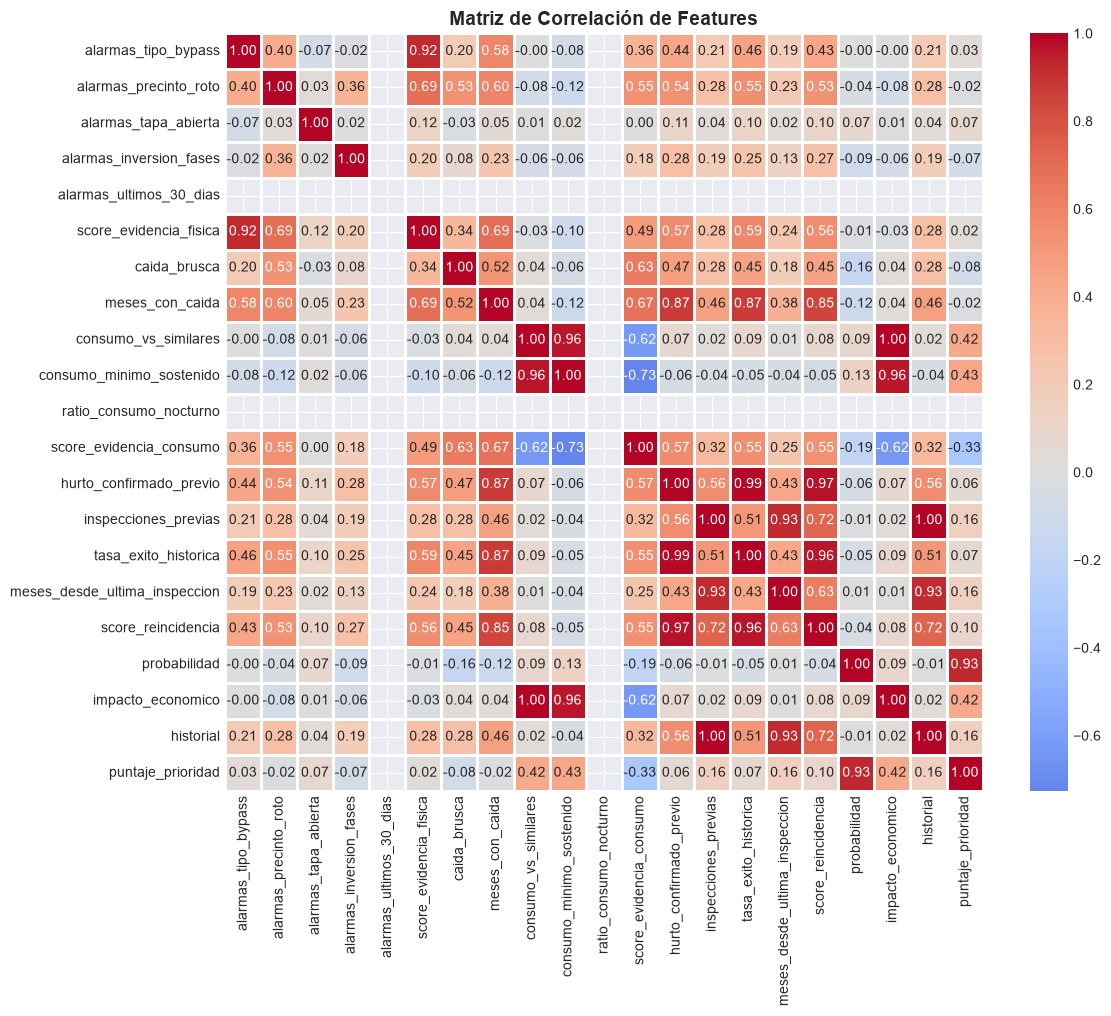

In [5]:
# ============================================================
# MATRIZ DE CORRELACIÓN
# ============================================================

if puntajes_path.exists() and features_num:
    # Calcular matriz de correlación
    corr_matrix = df[features_num].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1)
    plt.title('Matriz de Correlación de Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Importancia de Features

Revisamos la importancia de las features en el modelo entrenado.

📊 Importancia de Features:


,feature,importance
41,tasa_exito_historica,0.195644
40,inspecciones_con_hurto,0.179623
39,inspecciones_previas,0.167323
2,historial,0.080422
12,consumo_cv,0.037477
16,consumo_reciente,0.020221
4,consumo_media,0.017725
18,alarmas_total,0.016151
8,consumo_mediana,0.015600
7,consumo_maximo,0.015525


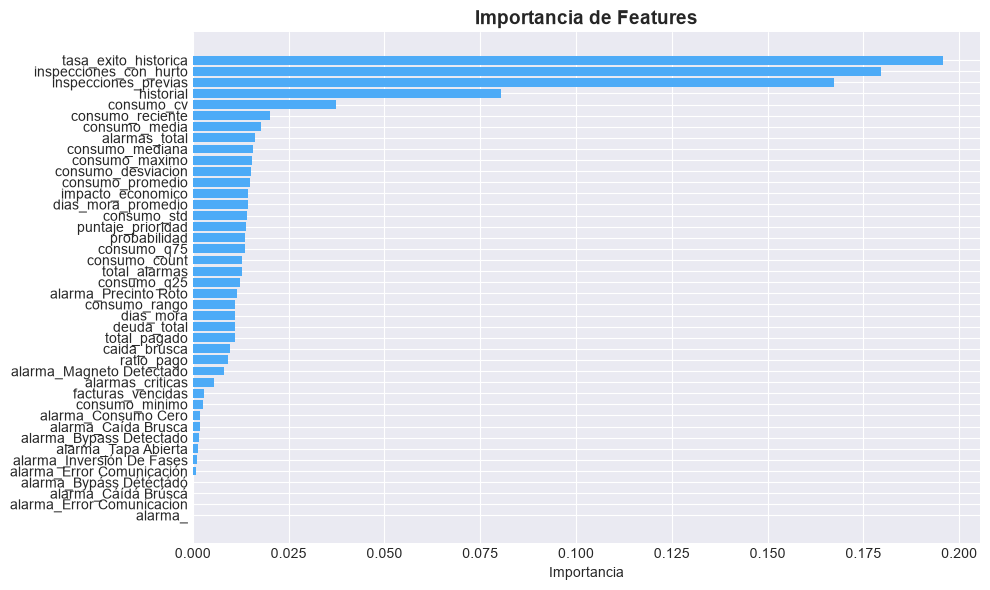

In [6]:
# ============================================================
# IMPORTANCIA DE FEATURES
# ============================================================

import joblib

modelo_path = Path('../modelos/actual/modelo_actual.pkl')

if modelo_path.exists():
    try:
        modelo_data = joblib.load(modelo_path)
        
        # Verificar si el modelo tiene importancia de features
        if isinstance(modelo_data, dict):
            modelo = modelo_data.get('modelo')
        else:
            modelo = modelo_data
        
        if hasattr(modelo, 'feature_importances_'):
            importancias = modelo.feature_importances_
            
            # Obtener nombres de features
            metrics_path = Path('../modelos/actual/metrics.json')
            if metrics_path.exists():
                with open(metrics_path, 'r', encoding='utf-8') as f:
                    metrics = json.load(f)
                    features_modelo = metrics.get('features_usadas', [])
            
            if not features_modelo or len(features_modelo) != len(importancias):
                features_modelo = [f'Feature {i}' for i in range(len(importancias))]
            
            # Crear DataFrame
            df_imp = pd.DataFrame({
                'feature': features_modelo,
                'importance': importancias
            }).sort_values('importance', ascending=False)
            
            print("📊 Importancia de Features:")
            display(df_imp)
            
            # Visualizar
            plt.figure(figsize=(10, 6))
            plt.barh(df_imp['feature'], df_imp['importance'], color='#4dabf7')
            plt.title('Importancia de Features', fontsize=14, fontweight='bold')
            plt.xlabel('Importancia')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
        else:
            print("⚠️ El modelo no tiene atributo feature_importances_")
            print(f"   Tipo de modelo: {type(modelo).__name__}")
    except Exception as e:
        print(f"⚠️ Error cargando modelo: {e}")
else:
    print("⚠️ No hay modelo entrenado")
    print("💡 Ejecuta: python scripts/ejecutar_flujo_completo.py")

## 5. Resumen de Features

Conclusiones del análisis de características.

In [7]:
# ============================================================
# RESUMEN
# ============================================================

print("=" * 60)
print("📊 RESUMEN DE FEATURES")
print("=" * 60)
print(f"📅 Fecha: {ahora_peru().strftime('%Y-%m-%d %H:%M:%S')} (Perú)")
print()

if puntajes_path.exists():
    print(f"📊 Features totales: {len(df.columns)}")
    print(f"📊 Features numéricas: {len(features_num)}")
    print(f"📊 Registros: {len(df)}")
    
    if 'prioridad' in df.columns:
        print(f"\n📊 Distribución de prioridades:")
        for prioridad, count in df['prioridad'].value_counts().items():
            print(f"   {prioridad}: {count} ({count/len(df)*100:.1f}%)")

print("\n" + "=" * 60)
print("✅ Análisis de features completado")
print("=" * 60)

📊 RESUMEN DE FEATURES
📅 Fecha: 2026-09-10 21:36:23 (Perú)

📊 Features totales: 44
📊 Features numéricas: 42
📊 Registros: 362

📊 Distribución de prioridades:
   BAJA: 121 (33.4%)
   ALTA: 121 (33.4%)
   MEDIA: 120 (33.1%)

✅ Análisis de features completado


In [8]:
# ============================================================
# DIAGNÓSTICO DE FEATURES
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# Cargar features
df = pd.read_parquet('../datos/procesados/puntajes_latest.parquet')

print("=" * 60)
print("🔍 DIAGNÓSTICO DE FEATURES")
print("=" * 60)

# Analizar cada feature
for col in ['probabilidad', 'impacto_economico', 'historial', 'puntaje_prioridad']:
    if col in df.columns:
        print(f"\n📊 {col}:")
        print(f"   Min:      {df[col].min():.4f}")
        print(f"   Max:      {df[col].max():.4f}")
        print(f"   Mean:     {df[col].mean():.4f}")
        print(f"   Std:      {df[col].std():.4f}")
        print(f"   Nulos:    {df[col].isna().sum()}")
        print(f"   Ceros:    {(df[col] == 0).sum()}")
        print(f"   Valores únicos: {df[col].nunique()}")

🔍 DIAGNÓSTICO DE FEATURES

📊 probabilidad:
   Min:      0.0051
   Max:      0.9901
   Mean:     0.4902
   Std:      0.2913
   Nulos:    0
   Ceros:    0
   Valores únicos: 362

📊 impacto_economico:
   Min:      0.0104
   Max:      1.0000
   Mean:     0.1243
   Std:      0.1678
   Nulos:    0
   Ceros:    0
   Valores únicos: 362

📊 historial:
   Min:      0.0000
   Max:      0.8406
   Mean:     0.1965
   Std:      0.1938
   Nulos:    0
   Ceros:    135
   Valores únicos: 182

📊 puntaje_prioridad:
   Min:      0.0132
   Max:      1.0000
   Mean:     0.4217
   Std:      0.2058
   Nulos:    0
   Ceros:    0
   Valores únicos: 362
